# Neural Network from Scratch

## Cell 1 — The Neuron

A **neuron** is the fundamental building block of a neural network.

It computes:

$$z = \mathbf{W} \cdot \mathbf{X} + b$$

Where:
- $\mathbf{X}$ = input vector
- $\mathbf{W}$ = weights vector (one weight per input)
- $b$ = bias (a scalar)
- $z$ = linear output (called **pre-activation**)

The weights tell the neuron how much to "care about" each input.  
The bias lets the neuron fire even when all inputs are zero.

We use **numpy** for math — no TensorFlow, no Keras.

In [1]:
import numpy as np

class Neuron:
    def __init__(self, n_inputs):
        # Random small weights for each input, and one bias
        # We subtract 0.5 to center them around zero (range: -0.5 to 0.5)
        self.weights = np.random.rand(n_inputs) - 0.5   # shape: (n_inputs,)
        self.bias    = np.random.rand(1)        - 0.5   # shape: (1,)

    def forward(self, X):
        """
        X: input vector of shape (n_inputs,)
        Returns z = W · X + b  (a single scalar)
        """
        z = np.dot(self.weights, X) + self.bias
        return z

# --- Quick test ---
neuron = Neuron(n_inputs=3)
sample_input = np.array([0.5, 0.2, 0.8])

z = neuron.forward(sample_input)
print(f"Weights : {neuron.weights}")
print(f"Bias    : {neuron.bias}")
print(f"Output z: {z}")   # z = w1*0.5 + w2*0.2 + w3*0.8 + b

Weights : [0.47634386 0.0311442  0.22763468]
Bias    : [0.2637322]
Output z: [0.69024072]


## Cell 3 — Visualizing What a Neuron Does

Let's break down the computation `z = W · X + b` visually.

Each input $x_i$ is multiplied by its weight $w_i$.  
The **weighted contributions** $w_i \cdot x_i$ are then summed up, and the bias is added.

The bar chart below shows how much each input actually *contributes* to the final output.

C:\Users\admin\AppData\Local\Temp\ipykernel_6284\2761168996.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias         = float(neuron.bias)
C:\Users\admin\AppData\Local\Temp\ipykernel_6284\2761168996.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[2].set_title(f"③ Weighted Contributions + Bias  →  z = {float(z):.4f}")
C:\Users\admin\AppData\Local\Temp\ipykernel_6284\2761168996.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[2].axhline(flo

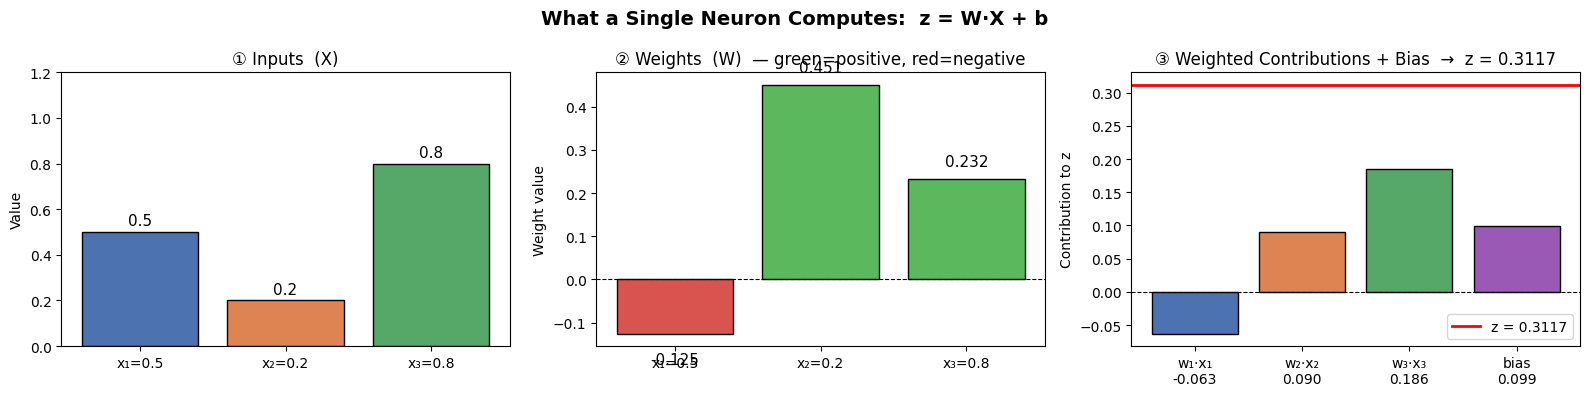


Manual check:  -0.0627 + 0.0901 + 0.1856 + 0.0987 = 0.3117
neuron.forward() returned: 0.3117


C:\Users\admin\AppData\Local\Temp\ipykernel_6284\2761168996.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"neuron.forward() returned: {float(z):.4f}")


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Reuse the neuron from Cell 2 ──────────────────────────────────────────────
np.random.seed(42)
neuron       = Neuron(n_inputs=3)
sample_input = np.array([0.5, 0.2, 0.8])
z            = neuron.forward(sample_input)

weights      = neuron.weights
bias         = float(neuron.bias)
contributions = weights * sample_input   # element-wise: wᵢ · xᵢ

labels = ['x₁=0.5', 'x₂=0.2', 'x₃=0.8']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("What a Single Neuron Computes:  z = W·X + b", fontsize=14, fontweight='bold')

# ── Plot 1: Inputs ────────────────────────────────────────────────────────────
axes[0].bar(labels, sample_input, color=colors, edgecolor='black')
axes[0].set_title("① Inputs  (X)")
axes[0].set_ylabel("Value")
axes[0].set_ylim(0, 1.2)
for i, v in enumerate(sample_input):
    axes[0].text(i, v + 0.03, f"{v}", ha='center', fontsize=11)

# ── Plot 2: Weights ───────────────────────────────────────────────────────────
bar_colors_w = ['#d9534f' if w < 0 else '#5cb85c' for w in weights]
axes[1].bar(labels, weights, color=bar_colors_w, edgecolor='black')
axes[1].set_title("② Weights  (W)  — green=positive, red=negative")
axes[1].set_ylabel("Weight value")
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(weights):
    axes[1].text(i, v + (0.03 if v >= 0 else -0.07), f"{v:.3f}", ha='center', fontsize=11)

# ── Plot 3: Weighted contributions + bias + z ─────────────────────────────────
bar_labels  = [f'w₁·x₁\n{contributions[0]:.3f}',
               f'w₂·x₂\n{contributions[1]:.3f}',
               f'w₃·x₃\n{contributions[2]:.3f}',
               f'bias\n{bias:.3f}']
bar_values  = list(contributions) + [bias]
bar_clrs    = ['#4C72B0', '#DD8452', '#55A868', '#9B59B6']
edge_colors = ['black'] * 4

axes[2].bar(bar_labels, bar_values, color=bar_clrs, edgecolor=edge_colors)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title(f"③ Weighted Contributions + Bias  →  z = {float(z):.4f}")
axes[2].set_ylabel("Contribution to z")

# Annotate total z as a horizontal line
axes[2].axhline(float(z), color='red', linewidth=2, linestyle='-', label=f'z = {float(z):.4f}')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nManual check:  {contributions[0]:.4f} + {contributions[1]:.4f} + {contributions[2]:.4f} + {bias:.4f} = {sum(contributions)+bias:.4f}")
print(f"neuron.forward() returned: {float(z):.4f}")

## Cell 4 — Why Do We Need Activation Functions? (ReLU)

Right now, `z = W·X + b` is a **linear** operation.  
If you stack many neurons doing only linear math, the whole network collapses into a single linear equation — it can't learn complex patterns.

We fix this by passing `z` through a **non-linear activation function**.

### ReLU — Rectified Linear Unit

$$\text{ReLU}(z) = \max(0, z)$$

- If `z > 0` → output is `z` (pass it through)
- If `z ≤ 0` → output is `0` (kill it)

**Why it works:** It introduces non-linearity while being dead simple to compute and differentiate.  
**Intuition:** The neuron "fires" only when its input is positive — like a biological neuron.

The derivative (used during backprop) is:
$$\text{ReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

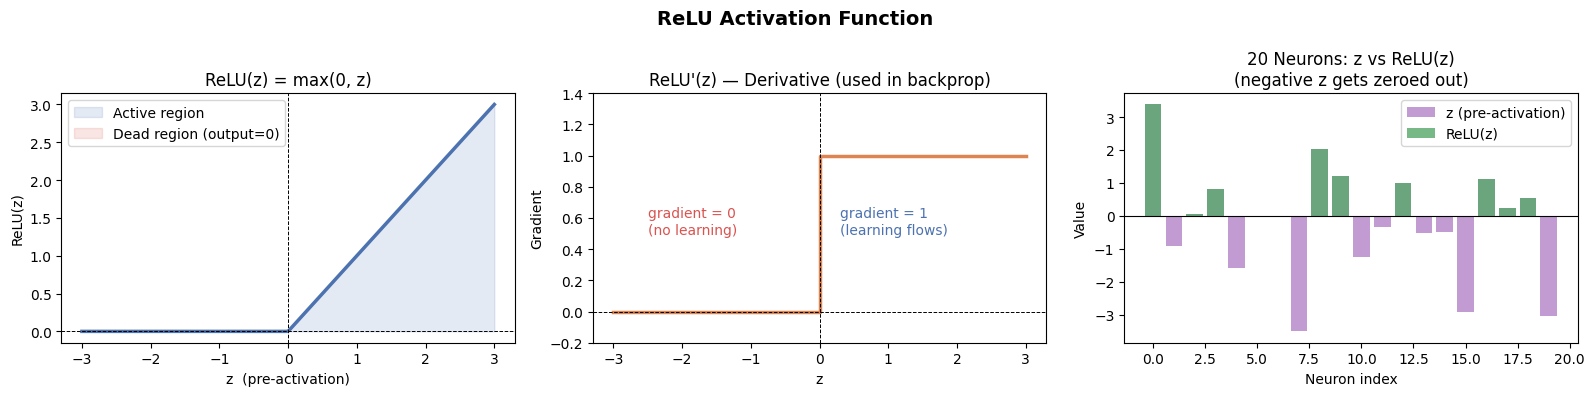

In [3]:
def ReLU(z):
    return np.maximum(0, z)

def ReLU_derivative(z):
    return (z > 0).astype(float)   # 1 where z>0, else 0

z_range = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("ReLU Activation Function", fontsize=14, fontweight='bold')

# ── Plot 1: ReLU curve ────────────────────────────────────────────────────────
axes[0].plot(z_range, ReLU(z_range), color='#4C72B0', linewidth=2.5)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].fill_between(z_range, 0, ReLU(z_range), where=(z_range > 0), alpha=0.15, color='#4C72B0', label='Active region')
axes[0].fill_between(z_range, 0, ReLU(z_range), where=(z_range <= 0), alpha=0.15, color='#d9534f',  label='Dead region (output=0)')
axes[0].set_title("ReLU(z) = max(0, z)")
axes[0].set_xlabel("z  (pre-activation)")
axes[0].set_ylabel("ReLU(z)")
axes[0].legend()

# ── Plot 2: ReLU derivative ───────────────────────────────────────────────────
axes[1].step(z_range, ReLU_derivative(z_range), color='#DD8452', linewidth=2.5, where='post')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title("ReLU'(z) — Derivative (used in backprop)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Gradient")
axes[1].set_ylim(-0.2, 1.4)
axes[1].text(-2.5, 0.5, "gradient = 0\n(no learning)", color='#d9534f', fontsize=10)
axes[1].text( 0.3, 0.5, "gradient = 1\n(learning flows)", color='#4C72B0', fontsize=10)

# ── Plot 3: Before vs After ReLU for sample neuron outputs ───────────────────
np.random.seed(7)
raw_z   = np.random.randn(20) * 2        # 20 random pre-activation values
after   = ReLU(raw_z)
x_idx   = np.arange(20)

axes[2].bar(x_idx, raw_z,  label='z (pre-activation)',  alpha=0.6, color='#9B59B6')
axes[2].bar(x_idx, after,  label='ReLU(z)',              alpha=0.8, color='#55A868')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title("20 Neurons: z vs ReLU(z)\n(negative z gets zeroed out)")
axes[2].set_xlabel("Neuron index")
axes[2].set_ylabel("Value")
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Cell 5 — From One Neuron to a Layer

A single neuron computes: $z = \mathbf{W} \cdot \mathbf{X} + b$

A **layer** stacks `n_neurons` neurons, each with its own weights, all reading the **same input** simultaneously.

$$Z = \mathbf{W} \cdot X + \mathbf{b}$$

| Symbol | Shape | Meaning |
|--------|-------|---------|
| $X$ | `(n_inputs, m)` | m input samples, each with n_inputs features |
| $\mathbf{W}$ | `(n_neurons, n_inputs)` | one row of weights per neuron |
| $\mathbf{b}$ | `(n_neurons, 1)` | one bias per neuron |
| $Z$ | `(n_neurons, m)` | raw output of every neuron for every sample |
| $A$ | `(n_neurons, m)` | after applying ReLU: $A = \text{ReLU}(Z)$ |

**Why this shape?**  
Each row of $\mathbf{W}$ belongs to one neuron. When we do $\mathbf{W} \cdot X$, each row (neuron) computes its dot product with every column (sample) of $X$ at once — that's the matrix multiplication doing all the work in one shot.

In [4]:
class Layer:
    def __init__(self, n_inputs, n_neurons):
        # W shape: (n_neurons, n_inputs) — one row of weights per neuron
        self.W = np.random.rand(n_neurons, n_inputs) - 0.5
        # b shape: (n_neurons, 1) — one bias per neuron
        self.b = np.random.rand(n_neurons, 1) - 0.5

    def forward(self, X):
        """
        X: shape (n_inputs, m) — m samples
        Z = W · X + b
        Returns Z of shape (n_neurons, m)
        """
        Z = self.W.dot(X) + self.b   # matrix multiply + broadcast bias
        return Z

# ── Quick test ────────────────────────────────────────────────────────────────
np.random.seed(42)

# Imagine 4 inputs, 3 neurons, 5 samples
layer        = Layer(n_inputs=4, n_neurons=3)
X_sample     = np.random.rand(4, 5)   # 4 features, 5 samples

Z = layer.forward(X_sample)
A = ReLU(Z)

print("Weight matrix W — shape:", layer.W.shape)
print(layer.W)
print("\nBias vector b — shape:", layer.b.shape)
print(layer.b)
print("\nInput X — shape:", X_sample.shape)
print("\nPre-activation Z = W·X + b — shape:", Z.shape)
print(Z)
print("\nPost-activation A = ReLU(Z) — shape:", A.shape)
print(A)

Weight matrix W — shape: (3, 4)
[[-0.12545988  0.45071431  0.23199394  0.09865848]
 [-0.34398136 -0.34400548 -0.44191639  0.36617615]
 [ 0.10111501  0.20807258 -0.47941551  0.46990985]]

Bias vector b — shape: (3, 1)
[[ 0.33244264]
 [-0.28766089]
 [-0.31817503]]

Input X — shape: (4, 5)

Pre-activation Z = W·X + b — shape: (3, 5)
[[ 0.82729911  0.42029108  0.5239977   0.67442759  0.60750634]
 [-0.68574306 -0.46609845 -0.77209496 -0.47661086 -0.21166464]
 [-0.26325449 -0.27398247 -0.42029057 -0.03639112  0.23765922]]

Post-activation A = ReLU(Z) — shape: (3, 5)
[[0.82729911 0.42029108 0.5239977  0.67442759 0.60750634]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.23765922]]


## Cell 7 — Visualizing a Layer

Three things to see:
1. **Matrix multiplication diagram** — how W, X, and Z relate in shape
2. **Heatmap of Z** — raw pre-activation outputs (can be negative)
3. **Heatmap of A = ReLU(Z)** — after activation (negatives zeroed out)

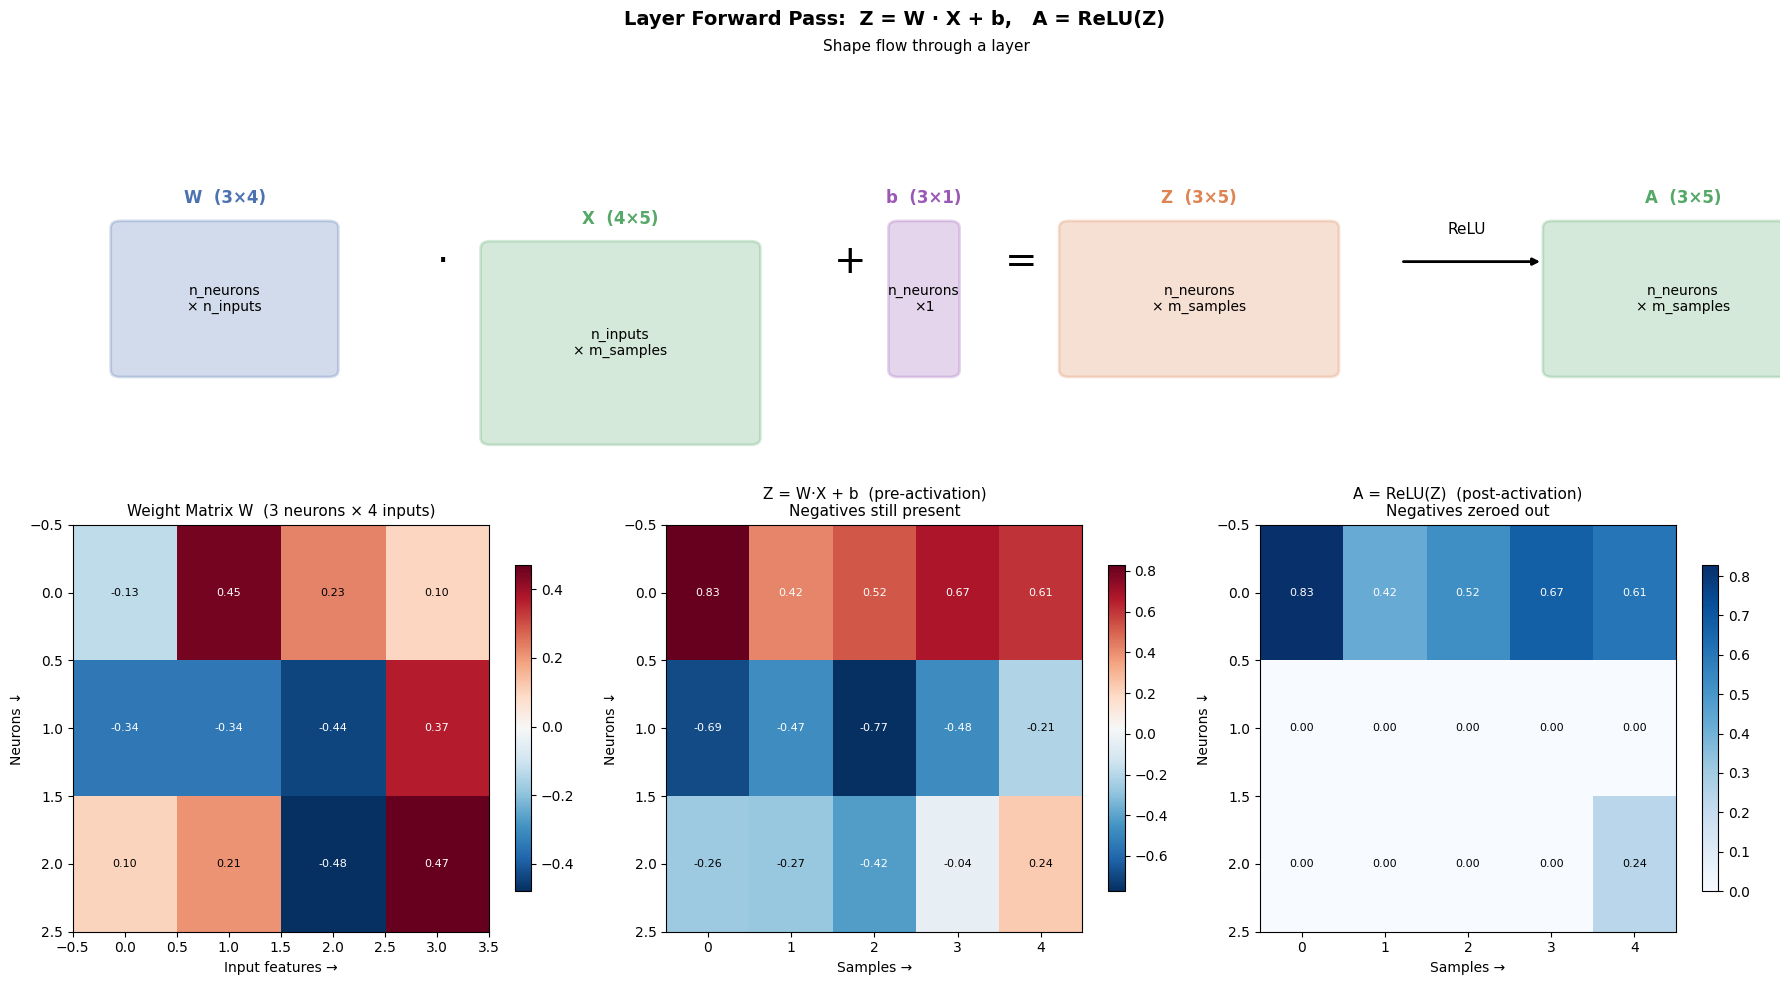

Negative values in Z: 9  →  after ReLU in A: 0
ReLU zeroed out 9 out of 15 values (60%)


In [5]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Layer Forward Pass:  Z = W · X + b,   A = ReLU(Z)", fontsize=14, fontweight='bold')

# ════════════════════════════════════════════════════════════════════════════════
# TOP ROW — Matrix multiplication diagram
# ════════════════════════════════════════════════════════════════════════════════
ax_diag = fig.add_subplot(2, 3, (1, 3))
ax_diag.set_xlim(0, 18)
ax_diag.set_ylim(0, 6)
ax_diag.axis('off')

def draw_matrix(ax, x, y, rows, cols, label, sublabel, color):
    w, h = cols * 0.55, rows * 0.7
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle="round,pad=0.1",
                                    linewidth=2, edgecolor=color,
                                    facecolor=color, alpha=0.25)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h + 0.3, label,    ha='center', va='bottom', fontsize=12, fontweight='bold', color=color)
    ax.text(x + w/2, y + h/2,     sublabel, ha='center', va='center',  fontsize=10, color='black')

# W: (3 neurons × 4 inputs)
draw_matrix(ax_diag, 0.5, 1.5, rows=3, cols=4, label="W  (3×4)", sublabel="n_neurons\n× n_inputs", color='#4C72B0')
# dot symbol
ax_diag.text(3.9, 3.1, "·", fontsize=28, ha='center', va='center', color='black')
# X: (4 inputs × 5 samples)
draw_matrix(ax_diag, 4.4, 0.5, rows=4, cols=5, label="X  (4×5)", sublabel="n_inputs\n× m_samples", color='#55A868')
# + symbol
ax_diag.text(8.2, 3.1, "+", fontsize=28, ha='center', va='center', color='black')
# b: (3 neurons × 1)
draw_matrix(ax_diag, 8.7, 1.5, rows=3, cols=1, label="b  (3×1)", sublabel="n_neurons\n×1", color='#9B59B6')
# = symbol
ax_diag.text(10.0, 3.1, "=", fontsize=28, ha='center', va='center', color='black')
# Z: (3 neurons × 5 samples)
draw_matrix(ax_diag, 10.5, 1.5, rows=3, cols=5, label="Z  (3×5)", sublabel="n_neurons\n× m_samples", color='#DD8452')
# ReLU arrow
ax_diag.annotate("", xy=(15.5, 3.1), xytext=(14.0, 3.1),
                 arrowprops=dict(arrowstyle="-|>", color='black', lw=2))
ax_diag.text(14.7, 3.5, "ReLU", ha='center', fontsize=11, color='black')
# A: (3 neurons × 5 samples)
draw_matrix(ax_diag, 15.6, 1.5, rows=3, cols=5, label="A  (3×5)", sublabel="n_neurons\n× m_samples", color='#55A868')

ax_diag.set_title("Shape flow through a layer", fontsize=11, pad=10)

# ════════════════════════════════════════════════════════════════════════════════
# BOTTOM ROW — Heatmaps of W, Z, and A
# ════════════════════════════════════════════════════════════════════════════════
ax_w = fig.add_subplot(2, 3, 4)
ax_z = fig.add_subplot(2, 3, 5)
ax_a = fig.add_subplot(2, 3, 6)

# Heatmap helper
def heatmap(ax, data, title, xlabel, ylabel, cmap, show_val=True):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, shrink=0.8)
    if show_val:
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(c, r, f"{data[r, c]:.2f}", ha='center', va='center',
                        fontsize=8, color='white' if abs(data[r,c]) > 0.3 else 'black')

heatmap(ax_w, layer.W,
        title="Weight Matrix W  (3 neurons × 4 inputs)",
        xlabel="Input features →", ylabel="Neurons ↓",
        cmap='RdBu_r')

heatmap(ax_z, Z,
        title="Z = W·X + b  (pre-activation)\nNegatives still present",
        xlabel="Samples →", ylabel="Neurons ↓",
        cmap='RdBu_r')

heatmap(ax_a, A,
        title="A = ReLU(Z)  (post-activation)\nNegatives zeroed out",
        xlabel="Samples →", ylabel="Neurons ↓",
        cmap='Blues')

plt.tight_layout()
plt.show()

# Summary
neg_z = np.sum(Z < 0)
neg_a = np.sum(A < 0)
print(f"Negative values in Z: {neg_z}  →  after ReLU in A: {neg_a}")
print(f"ReLU zeroed out {neg_z} out of {Z.size} values ({100*neg_z/Z.size:.0f}%)")

---
## Cell 8 — Why Does ReLU Actually Help?

### The Real Problem: Stacking Linear Layers is Useless Without Activation

Consider two layers with no activation:

$$Z^{[2]} = W^{[2]} \cdot (W^{[1]} \cdot X + b^{[1]}) + b^{[2]}$$

Expand it:

$$Z^{[2]} = \underbrace{(W^{[2]} W^{[1]})}_{\text{just a new matrix } W'} \cdot X + \underbrace{(W^{[2]} b^{[1]} + b^{[2]})}_{\text{just a new bias } b'}$$

**No matter how many layers you stack without activation, it always collapses to:** $Z = W' \cdot X + b'$

That's just **one linear layer**. The network can never learn curves, boundaries, or complex patterns — only straight lines.

### What ReLU Does

ReLU **breaks linearity** by treating positive and negative regions differently:
- When $z > 0$: neuron is **active**, gradient flows, the network can learn
- When $z \leq 0$: neuron is **silent** (output = 0), it's effectively removed from the computation

This means different neurons activate for different inputs — each neuron **specializes** in a region of the input space.

### Three Visualizations Below:
1. **Linear vs ReLU network** fitting a non-linear curve — linear fails, ReLU succeeds
2. **Proof of linear collapse** — two linear layers = one linear layer
3. **Neuron specialization** — each neuron "owns" a different region of the input

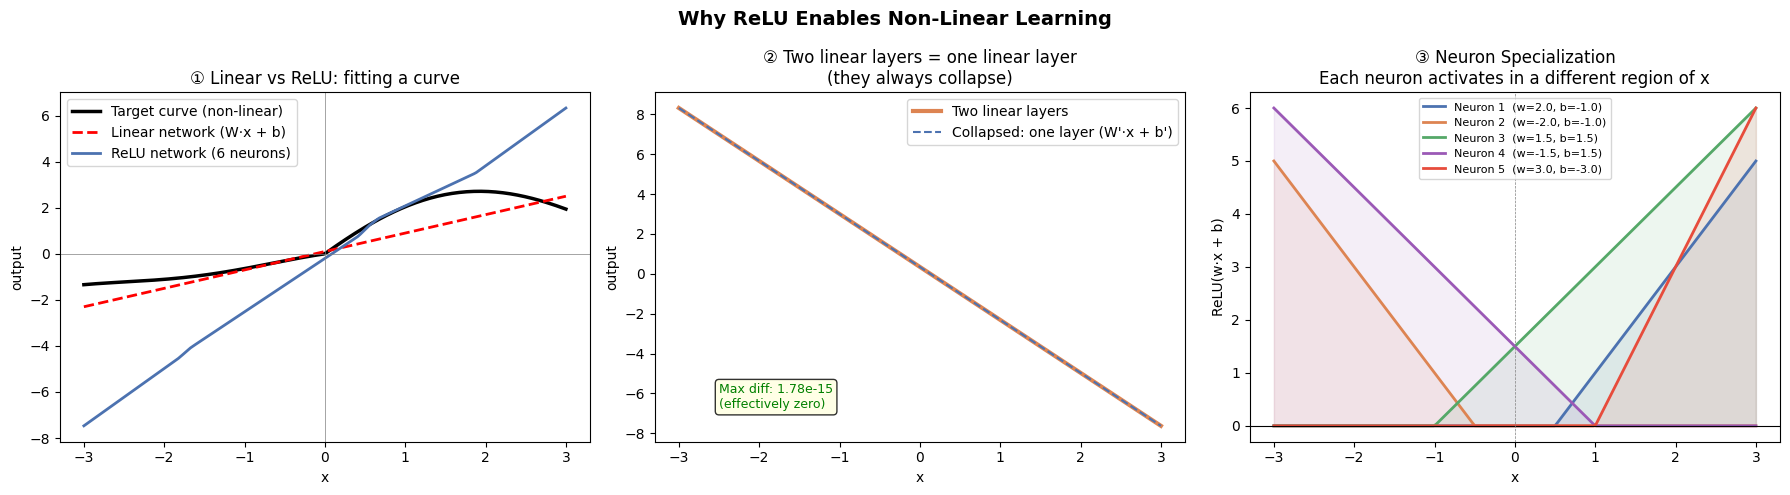

In [6]:
np.random.seed(0)
x = np.linspace(-3, 3, 200)

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 1 — Linear network vs ReLU network fitting a curve
# ════════════════════════════════════════════════════════════════════════════════

# Target: a non-linear curve (bent/curved shape)
y_target = np.where(x < 0, -0.5 * x, 1.5 * x) - 0.3 * x**2 + np.sin(x)

# Linear network output (just W·x + b — always a straight line no matter weights)
W_lin, b_lin = 0.8, 0.1
y_linear = W_lin * x + b_lin

# ReLU network: 6 hidden neurons, manually tuned to show piecewise fitting
# Each neuron fires in a different region — together they approximate the curve
def relu_network(x, W1, b1, W2, b2):
    # Hidden layer: (6,) neurons
    Z1 = np.outer(W1, x) + b1[:, None]   # (6, 200)
    A1 = ReLU(Z1)                          # (6, 200)
    # Output: scalar per input
    out = W2 @ A1 + b2                     # (1, 200)
    return out.flatten()

W1 = np.array([ 1.2, -1.5,  0.8, -0.9,  1.1, -0.6])
b1 = np.array([-0.5,  1.0, -1.5,  0.5,  2.0, -1.0])
W2 = np.array([[ 0.9, -0.7,  1.1, -0.8,  0.5, -1.2]])
b2 = np.array([-0.1])
y_relu = relu_network(x, W1, b1, W2, b2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Why ReLU Enables Non-Linear Learning", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(x, y_target, 'k-',       lw=2.5, label='Target curve (non-linear)')
ax.plot(x, y_linear, 'r--',      lw=2,   label='Linear network (W·x + b)')
ax.plot(x, y_relu,   '#4C72B0',  lw=2,   label='ReLU network (6 neurons)')
ax.set_title("① Linear vs ReLU: fitting a curve")
ax.set_xlabel("x")
ax.set_ylabel("output")
ax.legend()
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 2 — Proof: two linear layers = one linear layer
# ════════════════════════════════════════════════════════════════════════════════
ax = axes[1]

np.random.seed(5)
W1_l = np.random.randn(4, 1)     # Layer 1: 1 input → 4 neurons
b1_l = np.random.randn(4, 1)
W2_l = np.random.randn(1, 4)     # Layer 2: 4 neurons → 1 output
b2_l = np.random.randn(1, 1)

x_col = x.reshape(1, -1)         # (1, 200)

# Two separate linear layers (NO activation between them)
Z1_l  = W1_l @ x_col + b1_l     # (4, 200)
Z2_l  = W2_l @ Z1_l  + b2_l     # (1, 200) — two layer result

# Collapsed into one equivalent layer: W' = W2·W1,  b' = W2·b1 + b2
W_collapsed = W2_l @ W1_l        # (1, 1)
b_collapsed = W2_l @ b1_l + b2_l # (1, 1)
Z_collapsed = W_collapsed @ x_col + b_collapsed  # (1, 200)

ax.plot(x, Z2_l.flatten(),       color='#DD8452', lw=3,   label='Two linear layers')
ax.plot(x, Z_collapsed.flatten(), color='#4C72B0', lw=1.5, linestyle='--', label='Collapsed: one layer (W\'·x + b\')')
ax.set_title("② Two linear layers = one linear layer\n(they always collapse)")
ax.set_xlabel("x")
ax.set_ylabel("output")
ax.legend()

# Residual check
max_diff = np.max(np.abs(Z2_l - Z_collapsed))
ax.text(-2.5, ax.get_ylim()[0]*0.8, f"Max diff: {max_diff:.2e}\n(effectively zero)",
        fontsize=9, color='green',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 3 — Neuron specialization: each neuron fires in a different region
# ════════════════════════════════════════════════════════════════════════════════
ax = axes[2]

# 5 neurons with different weights/biases → each "owns" a different x region
neuron_W = [ 2.0, -2.0,  1.5, -1.5,  3.0]
neuron_b = [-1.0, -1.0,  1.5,  1.5, -3.0]
colors_n  = ['#4C72B0', '#DD8452', '#55A868', '#9B59B6', '#e74c3c']

for i, (w, b, c) in enumerate(zip(neuron_W, neuron_b, colors_n)):
    z_n = w * x + b
    a_n = ReLU(z_n)
    ax.plot(x, a_n, color=c, lw=2, label=f'Neuron {i+1}  (w={w}, b={b})')
    # Shade the active region
    ax.fill_between(x, 0, a_n, where=(a_n > 0), alpha=0.10, color=c)

ax.set_title("③ Neuron Specialization\nEach neuron activates in a different region of x")
ax.set_xlabel("x")
ax.set_ylabel("ReLU(w·x + b)")
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='gray',  lw=0.5, linestyle='--')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Cell 9 — The Full Network: Forward Pass

### Architecture

```
Input X  →  [Hidden Layer: ReLU]  →  [Output Layer: Softmax]  →  Probabilities
(784,m)       (128, m)                  (10, m)                    (10, m)
```

### Why Softmax on the Output?

ReLU is used in hidden layers. The output layer needs something different — we want **probabilities** (values between 0 and 1 that sum to 1), so we can say "this image is 87% likely to be a 3".

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

- Takes a vector of raw scores (called **logits**) — any real number
- Converts them to probabilities that **sum to exactly 1**
- The largest logit gets the highest probability
- The `argmax` of the output = the predicted class

### Full Forward Pass (two-layer network)

$$Z^{[1]} = W^{[1]} \cdot X + b^{[1]}$$
$$A^{[1]} = \text{ReLU}(Z^{[1]})$$
$$Z^{[2]} = W^{[2]} \cdot A^{[1]} + b^{[2]}$$
$$A^{[2]} = \text{Softmax}(Z^{[2]})$$

$A^{[2]}$ is the final output — a probability distribution over all classes for each sample.

In [ ]:
def softmax(Z):
    """
    Z: shape (n_classes, m)
    Subtracting max(Z) per column is a numerical stability trick —
    prevents e^(very large number) from overflowing to inf.
    The result is mathematically identical.
    """
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)  # shift each column
    expZ = np.exp(Z_stable)
    return expZ / np.sum(expZ, axis=0, keepdims=True)


class NeuralNetwork:
    def __init__(self, n_inputs, n_hidden, n_outputs):
        """
        n_inputs  : number of features per sample (e.g. 784 for 28x28 images)
        n_hidden  : number of neurons in the hidden layer
        n_outputs : number of classes (e.g. 10 for digits 0-9)
        """
        self.hidden = Layer(n_inputs,  n_hidden)   # W1, b1
        self.output = Layer(n_hidden, n_outputs)   # W2, b2

    def forward(self, X):
        """
        X: shape (n_inputs, m)
        Returns all intermediate values — needed later for backprop.
        """
        # Hidden layer
        self.Z1 = self.hidden.W.dot(X) + self.hidden.b   # (n_hidden, m)
        self.A1 = ReLU(self.Z1)                           # (n_hidden, m)

        # Output layer
        self.Z2 = self.output.W.dot(self.A1) + self.output.b  # (n_outputs, m)
        self.A2 = softmax(self.Z2)                             # (n_outputs, m)

        return self.A2

    def predict(self, X):
        """Returns the predicted class index for each sample."""
        probs = self.forward(X)
        return np.argmax(probs, axis=0)   # index of highest probability


# ── Quick test ─────────────────────────────────────────────────────────────────
np.random.seed(42)

# Simulating MNIST-like data: 784 inputs, 128 hidden neurons, 10 output classes
nn = NeuralNetwork(n_inputs=784, n_hidden=128, n_outputs=10)

X_test    = np.random.rand(784, 5)   # 5 fake samples
probs     = nn.forward(X_test)
preds     = nn.predict(X_test)

print("Shape check:")
print(f"  Z1 (hidden pre-activation) : {nn.Z1.shape}")
print(f"  A1 (hidden post-ReLU)      : {nn.A1.shape}")
print(f"  Z2 (output pre-softmax)    : {nn.Z2.shape}")
print(f"  A2 (output probabilities)  : {nn.A2.shape}")
print(f"\nOutput probabilities for first sample (must sum to 1.0):")
print(np.round(probs[:, 0], 4))
print(f"Sum: {probs[:, 0].sum():.6f}")
print(f"\nPredicted classes for 5 samples: {preds}")

## Cell 11 — Visualizing Softmax + Full Network Data Flow